## RUS vs SMOTE (Random Forest)

Membandingkan RUS dan SMOTE untuk prediksi severity maintenance.

Rasio uji :
RUS25, RUS50, RUS75, RUS100, SMOTE25, SMOTE50, SMOTE75, SMOTE100.

In [98]:
%pip install pandas numpy scikit-learn imbalanced-learn matplotlib seaborn sqlalchemy pymysql --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [99]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

from collections import Counter
from sqlalchemy import create_engine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
np.random.seed(42)

print("All libraries imported successfully.")

All libraries imported successfully.


## Koneksi Database & Ambil Data

In [100]:
DB_HOST     = os.getenv('DB_HOST', 'localhost')
DB_PORT     = int(os.getenv('DB_PORT', '3306'))
DB_USER     = os.getenv('DB_USER', 'root')
DB_PASSWORD = os.getenv('DB_PASSWORD', '')
DB_NAME     = os.getenv('DB_NAME', 'datawarehouse_om')

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
print(f"Connection ready: {DB_HOST}:{DB_PORT}/{DB_NAME}")

Connection ready: localhost:3306/datawarehouse_om


In [101]:
query = """
    SELECT
        f.fact_id,
        f.severity,
        t.month,
        m.scope_of_work,
        s.city,
        s.site_code
    FROM fact_maintenance_activity f
    JOIN dim_time             t  ON f.time_id        = t.time_id
    JOIN dim_maintenance_type m  ON f.maintenance_id = m.maintenance_id
    JOIN dim_site             s  ON f.site_id        = s.site_id
        AND s.is_current = 1
"""

df = pd.read_sql(query, con=engine)
print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(df.head(3))

Data loaded: 52,427 rows × 6 columns
   fact_id severity  month scope_of_work                 city   site_code
0     1421    minor      1            q2  kabupaten bondowoso  bdw-07-001
1     5963    minor      2            b4  kabupaten bondowoso  bdw-07-001
2     9883    minor      3           vw2  kabupaten bondowoso  bdw-07-001


## Data Preparation

In [102]:
# Conversion & encoding
FEATURE_COLS = ['month', 'scope_of_work', 'city', 'site_code']
TARGET_COL   = 'severity'
CAT_COLS     = ['scope_of_work', 'city', 'site_code']

df['month'] = pd.to_numeric(df['month'], errors='coerce')

label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str).str.strip().str.lower())
    label_encoders[col] = le
    print(f"  Encoded '{col}' → {len(le.classes_)} unique classes")

df['severity_encoded'] = df[TARGET_COL].str.strip().str.lower().map({'minor': 0, 'major': 1})

X = df[FEATURE_COLS].copy()
y = df['severity_encoded'].copy()

# Original class distribution
sev_counts = Counter(y)
total      = len(y)
ratio_ori  = sev_counts[0] / sev_counts[1]

print(f"\nClass distribution:")
print(f"  Minor (0): {sev_counts[0]:<0.0f} ({sev_counts[0]/total*100:.1f}%)")
print(f"  Major (1): {sev_counts[1]:<0.0f}  ({sev_counts[1]/total*100:.1f}%)")
print(f"  Imbalance ratio  : {ratio_ori:.2f}:1")

  Encoded 'scope_of_work' → 52 unique classes
  Encoded 'city' → 31 unique classes
  Encoded 'site_code' → 8033 unique classes

Class distribution:
  Minor (0): 42796 (81.6%)
  Major (1): 9631  (18.4%)
  Imbalance ratio  : 4.44:1


In [103]:
# Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n_minor_train = Counter(y_train)[1]   # jumlah major (minoritas) di training
n_major_train = Counter(y_train)[0]   # jumlah minor (mayoritas) di training

print(f"Training : {len(X_train):<0.0f} baris | minor = {n_major_train:<0.0f} & major = {n_minor_train:<0.0f}")
print(f"Testing  : {len(X_test):<0.0f} baris")

Training : 41941 baris | minor = 34236 & major = 7705
Testing  : 10486 baris


## Variasi Rasio Resampling

In [104]:
# Definisi resampling
# 1.0 = 1:1 (100%), 0.75 = 75%, 0.50 = 50%, 0.25 = 25%

RATIOS = [0.25, 0.50, 0.75, 1.00]
RATIO_LABELS = ['25%', '50%', '75%', '100%']

CONFIGS = []

# RUS configs
for ratio, label in zip(RATIOS, RATIO_LABELS):
    CONFIGS.append({
        'name'    : f'RUS{int(ratio*100)}',
        'method'  : 'RUS',
        'ratio'   : ratio,
        'label'   : label,
        'resampler': RandomUnderSampler(sampling_strategy=ratio, random_state=42)
    })

# SMOTE configs
for ratio, label in zip(RATIOS, RATIO_LABELS):
    CONFIGS.append({
        'name'    : f'SMOTE{int(ratio*100)}',
        'method'  : 'SMOTE',
        'ratio'   : ratio,
        'label'   : label,
        'resampler': SMOTE(sampling_strategy=ratio, random_state=42, k_neighbors=5)
    })

# Preview distribusi data
print(f"{'Config':<12} {'Strategi':<12} {'Rasio':>8} {'Minor':>10} {'Major':>10} {'Total':>10}")
print("-" * 65)
for cfg in CONFIGS:
    try:
        rs = cfg['resampler']
        _, y_res = rs.fit_resample(X_train, y_train)
        c = Counter(y_res)
        print(f"{cfg['name']:<12} {cfg['method']:<12} {cfg['label']:>8} {c[0]:>10.0f} {c[1]:>10.0f} {len(y_res):>10.0f}")
    except Exception as e:
        print(f"{cfg['name']:<12} ERROR: {e}")

Config       Strategi        Rasio      Minor      Major      Total
-----------------------------------------------------------------
RUS25        RUS               25%      30820       7705      38525
RUS50        RUS               50%      15410       7705      23115
RUS75        RUS               75%      10273       7705      17978
RUS100       RUS              100%       7705       7705      15410
SMOTE25      SMOTE             25%      34236       8559      42795
SMOTE50      SMOTE             50%      34236      17118      51354
SMOTE75      SMOTE             75%      34236      25677      59913
SMOTE100     SMOTE            100%      34236      34236      68472


## 10-Fold Cross-Validation

In [105]:
RF_PARAMS = dict(n_estimators=100, random_state=42, n_jobs=-1)
skf       = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
SCORING   = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

cv_results_all = []

for cfg in CONFIGS:
    print(f"  CV: {cfg['name']} |", end=' ')

    pipeline = ImbPipeline([
        ('resampler', cfg['resampler']),
        ('clf',       RandomForestClassifier(**RF_PARAMS))
    ])

    cv_res = cross_validate(
        pipeline, X, y,
        cv      = skf,
        scoring = SCORING,
        n_jobs  = -1
    )

    cv_results_all.append({
        'name'      : cfg['name'],
        'method'    : cfg['method'],
        'ratio'     : cfg['ratio'],
        'label'     : cfg['label'],
        'cv_acc'    : cv_res['test_accuracy'].mean(),
        'cv_acc_std': cv_res['test_accuracy'].std(),
        'cv_prec'   : cv_res['test_precision_weighted'].mean(),
        'cv_rec'    : cv_res['test_recall_weighted'].mean(),
        'cv_f1'     : cv_res['test_f1_weighted'].mean(),
        'cv_f1_std' : cv_res['test_f1_weighted'].std(),
        'cv_raw_acc': cv_res['test_accuracy'],
    })
    print(f"Accuracy = {cv_res['test_accuracy'].mean():.3f} ± {cv_res['test_accuracy'].std():.3f}")

print("\nAll CV is done.")

  CV: RUS25 | Accuracy = 0.770 ± 0.008
  CV: RUS50 | Accuracy = 0.738 ± 0.008
  CV: RUS75 | Accuracy = 0.713 ± 0.009
  CV: RUS100 | Accuracy = 0.696 ± 0.008
  CV: SMOTE25 | Accuracy = 0.771 ± 0.008
  CV: SMOTE50 | Accuracy = 0.754 ± 0.009
  CV: SMOTE75 | Accuracy = 0.743 ± 0.008
  CV: SMOTE100 | Accuracy = 0.735 ± 0.008

All CV is done.


In [106]:
# Tabel hasil CV
df_cv = pd.DataFrame(cv_results_all)

print("10-FOLD CROSS VALIDATION\n")

print(f"{'Config':<12} {'Method':<8} {'Rasio':>6} {'Accuracy':>13} {'Precision':>12} {'Recall':>10} {'F1-Score':>10}")
print("-"*80)

prev_method = ''
for _, row in df_cv.iterrows():
    if row['method'] != prev_method and prev_method != '':
        print("-"*80)
    prev_method = row['method']
    print(f"{row['name']:<12} {row['method']:<8} {row['label']:>6} "
          f"{row['cv_acc']:.3f} ± {row['cv_acc_std']:.3f} "
          f"{row['cv_prec']:>12.3f} "
          f"{row['cv_rec']:>10.3f} "
          f"{row['cv_f1']:>10.3f}")

# Highlight
best_acc_idx = df_cv['cv_acc'].idxmax()
best_f1_idx  = df_cv['cv_f1'].idxmax()
print(f"\n- Accuracy tertinggi : {df_cv.loc[best_acc_idx,'name']} ({df_cv.loc[best_acc_idx,'cv_acc']:.3f})")
print(f"- F1-Score tertinggi : {df_cv.loc[best_f1_idx,'name']} ({df_cv.loc[best_f1_idx,'cv_f1']:.3f})")

10-FOLD CROSS VALIDATION

Config       Method    Rasio      Accuracy    Precision     Recall   F1-Score
--------------------------------------------------------------------------------
RUS25        RUS         25% 0.770 ± 0.008        0.771      0.770      0.771
RUS50        RUS         50% 0.738 ± 0.008        0.788      0.738      0.756
RUS75        RUS         75% 0.713 ± 0.009        0.798      0.713      0.740
RUS100       RUS        100% 0.696 ± 0.008        0.808      0.696      0.728
--------------------------------------------------------------------------------
SMOTE25      SMOTE       25% 0.771 ± 0.008        0.769      0.771      0.770
SMOTE50      SMOTE       50% 0.754 ± 0.009        0.774      0.754      0.763
SMOTE75      SMOTE       75% 0.743 ± 0.008        0.778      0.743      0.758
SMOTE100     SMOTE      100% 0.735 ± 0.008        0.781      0.735      0.753

- Accuracy tertinggi : SMOTE25 (0.771)
- F1-Score tertinggi : RUS25 (0.771)


## Final (Data Testing)

In [107]:
test_results_all = []

for cfg in CONFIGS:
    print(f"  Training & Testing: {cfg['name']} |", end=' ')

    # Resample training data
    rs = cfg['resampler']
    X_res, y_res = rs.fit_resample(X_train, y_train)

    # Train final model
    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(X_res, y_res)

    # Predict on original test set
    y_pred      = rf.predict(X_test)
    y_pred_prob = rf.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)

    test_results_all.append({
        'name'        : cfg['name'],
        'method'      : cfg['method'],
        'ratio'       : cfg['ratio'],
        'label'       : cfg['label'],
        # Overall metrics
        'acc'         : accuracy_score(y_test, y_pred),
        'prec_w'      : precision_score(y_test, y_pred, average='weighted'),
        'rec_w'       : recall_score(y_test, y_pred, average='weighted'),
        'f1_w'        : f1_score(y_test, y_pred, average='weighted'),
        'auc'         : roc_auc_score(y_test, y_pred_prob),
        # Per-class metrics
        'prec_minor'  : precision_score(y_test, y_pred, pos_label=0),
        'rec_minor'   : recall_score(y_test, y_pred, pos_label=0),
        'f1_minor'    : f1_score(y_test, y_pred, pos_label=0),
        'prec_major'  : precision_score(y_test, y_pred, pos_label=1),
        'rec_major'   : recall_score(y_test, y_pred, pos_label=1),
        'f1_major'    : f1_score(y_test, y_pred, pos_label=1),
        # Confusion matrix
        'TP': cm[1][1], 'FP': cm[0][1],
        'TN': cm[0][0], 'FN': cm[1][0],
        # Training size
        'n_train'     : len(y_res),
        'n_minor_res' : Counter(y_res)[0],
        'n_major_res' : Counter(y_res)[1],
    })
    print(f"Acc = {test_results_all[-1]['acc']:.3f} & AUC = {test_results_all[-1]['auc']:.3f}")

df_test = pd.DataFrame(test_results_all)
print("\nSemua model selesai dilatih dan dievaluasi.")

  Training & Testing: RUS25 | Acc = 0.772 & AUC = 0.780
  Training & Testing: RUS50 | Acc = 0.742 & AUC = 0.787
  Training & Testing: RUS75 | Acc = 0.714 & AUC = 0.786
  Training & Testing: RUS100 | Acc = 0.697 & AUC = 0.788
  Training & Testing: SMOTE25 | Acc = 0.774 & AUC = 0.774
  Training & Testing: SMOTE50 | Acc = 0.758 & AUC = 0.773
  Training & Testing: SMOTE75 | Acc = 0.748 & AUC = 0.768
  Training & Testing: SMOTE100 | Acc = 0.736 & AUC = 0.767

Semua model selesai dilatih dan dievaluasi.


In [108]:
# Testing results table
print("TEST DATA EVALUATION RESULTS\n")
print(f"{'Config':<10} {'Ratio':>6} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-"*70)

prev_method = ''
for _, row in df_test.iterrows():
    if row['method'] != prev_method and prev_method != '':
        print("-"*70)
    prev_method = row['method']
    print(f"{row['name']:<10} {row['label']:>6} "
          f"{row['acc']:>10.3f} {row['prec_w']:>10.3f} "
          f"{row['rec_w']:>8.3f} {row['f1_w']:>8.3f} {row['auc']:>8.3f}")

best_acc = df_test.loc[df_test['acc'].idxmax()]
best_f1  = df_test.loc[df_test['f1_w'].idxmax()]
best_auc = df_test.loc[df_test['auc'].idxmax()]
best_rec_major = df_test.loc[df_test['rec_major'].idxmax()]

print(f"\n- Highest accuracy     : {best_acc['name']} ({best_acc['acc']:.3f})")
print(f"- Highest F1-Score    : {best_f1['name']}   ({best_f1['f1_w']:.3f})")
print(f"- Highest ROC-AUC     : {best_auc['name']}  ({best_auc['auc']:.3f})")
print(f"- Highest Recall Major: {best_rec_major['name']}  ({best_rec_major['rec_major']:.3f})")

TEST DATA EVALUATION RESULTS

Config      Ratio   Accuracy  Precision   Recall       F1      AUC
----------------------------------------------------------------------
RUS25         25%      0.772      0.775    0.772    0.773    0.780
RUS50         50%      0.742      0.792    0.742    0.760    0.787
RUS75         75%      0.714      0.802    0.714    0.742    0.786
RUS100       100%      0.697      0.812    0.697    0.729    0.788
----------------------------------------------------------------------
SMOTE25       25%      0.774      0.772    0.774    0.773    0.774
SMOTE50       50%      0.758      0.778    0.758    0.767    0.773
SMOTE75       75%      0.748      0.780    0.748    0.761    0.768
SMOTE100     100%      0.736      0.781    0.736    0.754    0.767

- Highest accuracy     : SMOTE25 (0.774)
- Highest F1-Score    : RUS25   (0.773)
- Highest ROC-AUC     : RUS100  (0.788)
- Highest Recall Major: RUS100  (0.721)


## Visualisasi Perbandingan

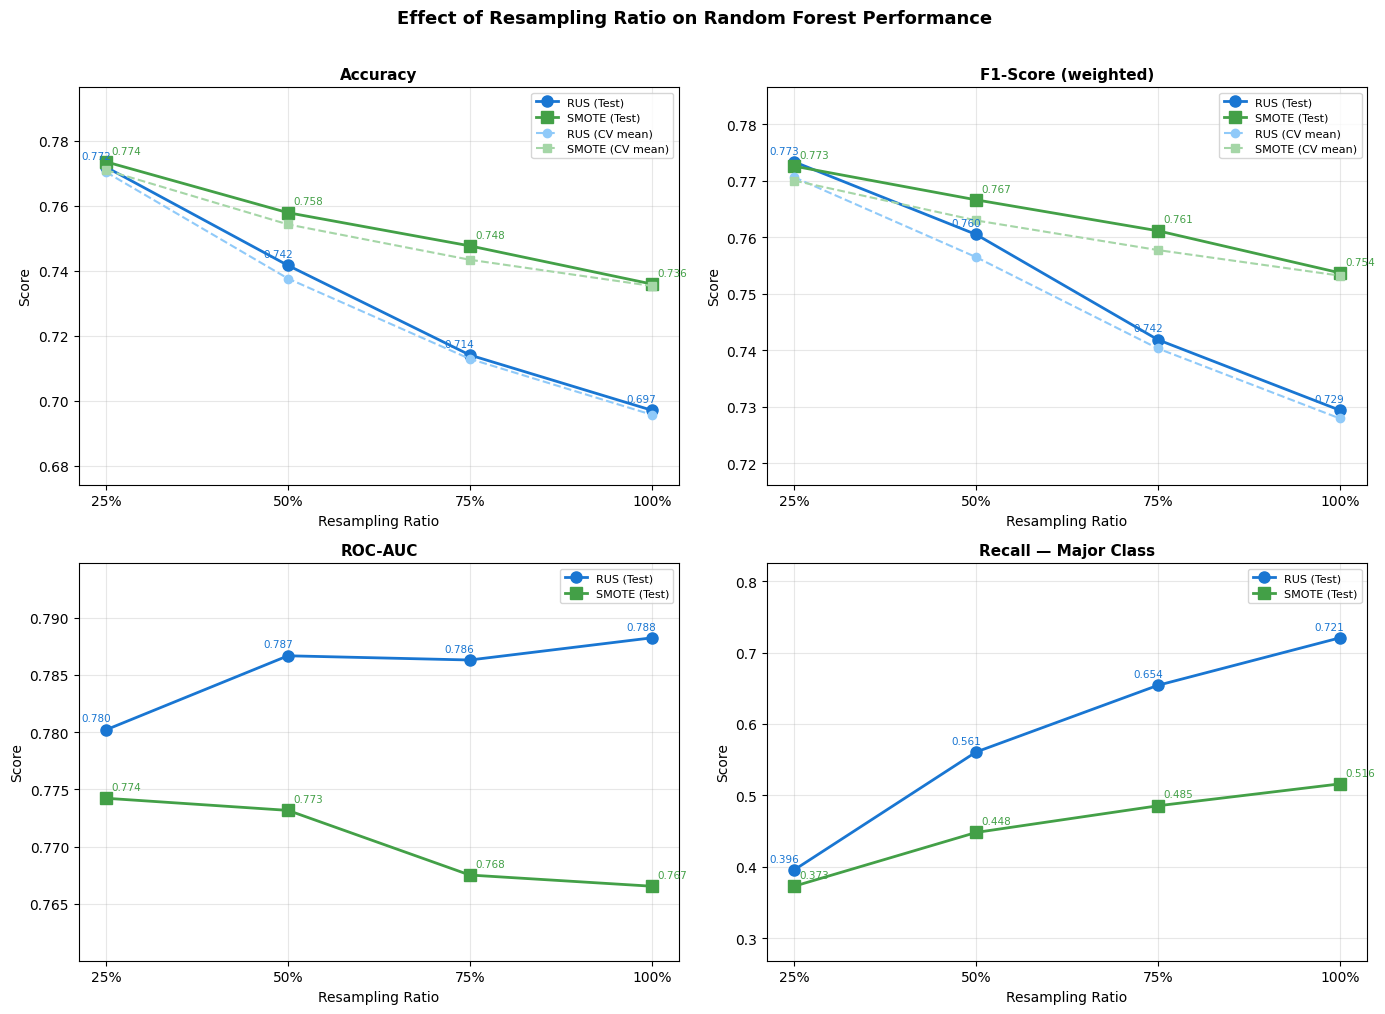

In [109]:
# 1: RUS vs SMOTE
df_rus   = df_test[df_test['method'] == 'RUS'].sort_values('ratio')
df_smote = df_test[df_test['method'] == 'SMOTE'].sort_values('ratio')
df_cv_rus   = df_cv[df_cv['method'] == 'RUS'].sort_values('ratio')
df_cv_smote = df_cv[df_cv['method'] == 'SMOTE'].sort_values('ratio')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Effect of Resampling Ratio on Random Forest Performance',
             fontsize=13, fontweight='bold', y=1.01)

x_ticks = RATIO_LABELS
x_pos   = [0, 1, 2, 3]

metric_plots = [
    ('acc',   'cv_acc',  'Accuracy',             axes[0, 0]),
    ('f1_w',  'cv_f1',   'F1-Score (weighted)',  axes[0, 1]),
    ('auc',   None,      'ROC-AUC',              axes[1, 0]),
    ('rec_major', None,  'Recall — Major Class', axes[1, 1]),
]

for test_col, cv_col, title, ax in metric_plots:
    ax.plot(x_pos, df_rus[test_col].values,   'o-', color='#1976D2', linewidth=2,
            markersize=8, label='RUS (Test)')
    ax.plot(x_pos, df_smote[test_col].values, 's-', color='#43A047', linewidth=2,
            markersize=8, label='SMOTE (Test)')

    if cv_col:
        ax.plot(x_pos, df_cv_rus[cv_col].values,   'o--', color='#90CAF9', linewidth=1.5,
                markersize=6, label='RUS (CV mean)')
        ax.plot(x_pos, df_cv_smote[cv_col].values, 's--', color='#A5D6A7', linewidth=1.5,
                markersize=6, label='SMOTE (CV mean)')

    for xi, (v_rus, v_smote) in enumerate(zip(df_rus[test_col].values, df_smote[test_col].values)):
        ax.annotate(f'{v_rus:.3f}', (xi, v_rus),
                    textcoords='offset points', xytext=(-18, 6), fontsize=7.5, color='#1976D2')
        ax.annotate(f'{v_smote:.3f}', (xi, v_smote),
                    textcoords='offset points', xytext=(4, 6), fontsize=7.5, color='#43A047')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_ticks)
    ax.set_xlabel('Resampling Ratio')
    ax.set_ylabel('Score')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    y_vals = list(df_rus[test_col].values) + list(df_smote[test_col].values)
    margin = (max(y_vals) - min(y_vals)) * 0.3
    ax.set_ylim(max(0, min(y_vals) - margin), min(1.05, max(y_vals) + margin))

plt.tight_layout()
plt.show()

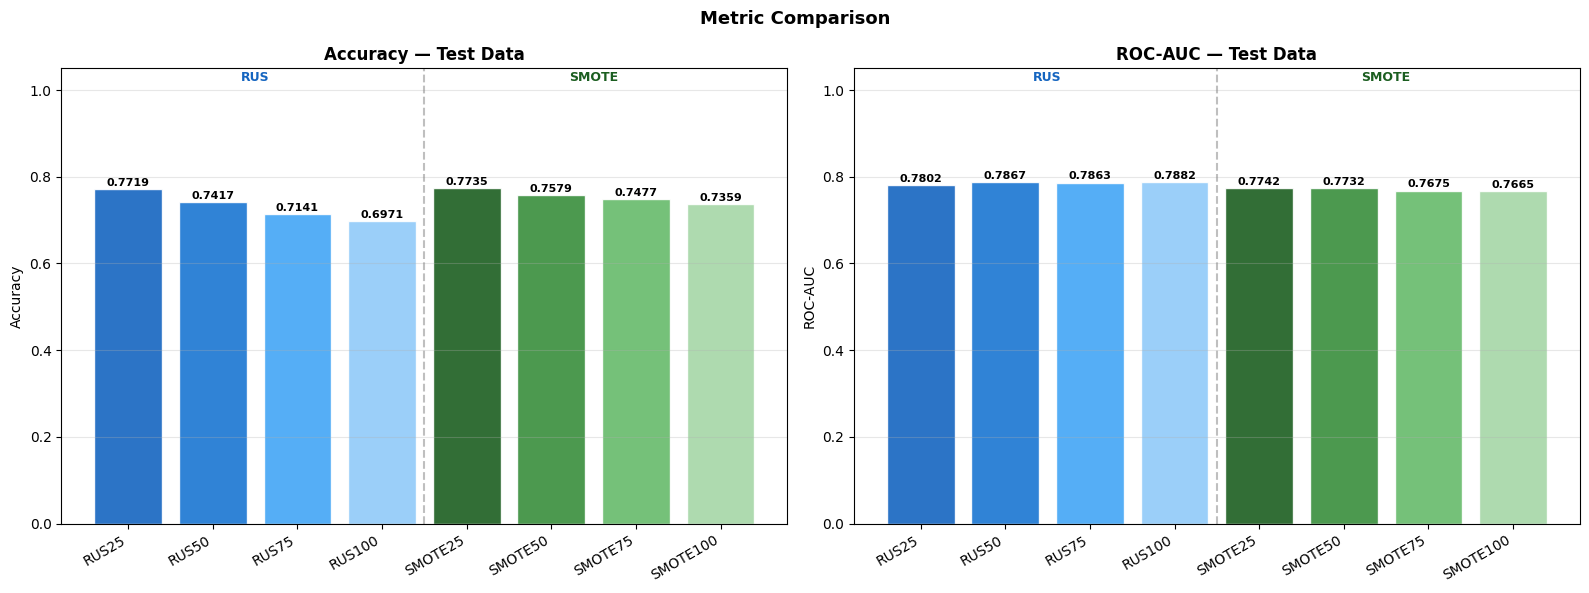

In [110]:
# 2: Bar chart comparison of all configs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Metric Comparison',
             fontsize=13, fontweight='bold')

configs_names = df_test['name'].tolist()
x_all = np.arange(len(configs_names))
colors_bar = ['#1565C0','#1976D2','#42A5F5','#90CAF9',
               '#1B5E20','#388E3C','#66BB6A','#A5D6A7']

ax1 = axes[0]
bars = ax1.bar(x_all, df_test['acc'], color=colors_bar, alpha=0.9, edgecolor='white')
for bar, val in zip(bars, df_test['acc']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.set_xticks(x_all)
ax1.set_xticklabels(configs_names, rotation=30, ha='right')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy — Test Data', fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5)
ax1.text(1.5, 1.02, 'RUS', ha='center', fontsize=9, color='#1565C0', fontweight='bold')
ax1.text(5.5, 1.02, 'SMOTE', ha='center', fontsize=9, color='#1B5E20', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bars2 = ax2.bar(x_all, df_test['auc'], color=colors_bar, alpha=0.9, edgecolor='white')
for bar, val in zip(bars2, df_test['auc']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.set_xticks(x_all)
ax2.set_xticklabels(configs_names, rotation=30, ha='right')
ax2.set_ylabel('ROC-AUC')
ax2.set_title('ROC-AUC — Test Data', fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5)
ax2.text(1.5, 1.02, 'RUS', ha='center', fontsize=9, color='#1565C0', fontweight='bold')
ax2.text(5.5, 1.02, 'SMOTE', ha='center', fontsize=9, color='#1B5E20', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

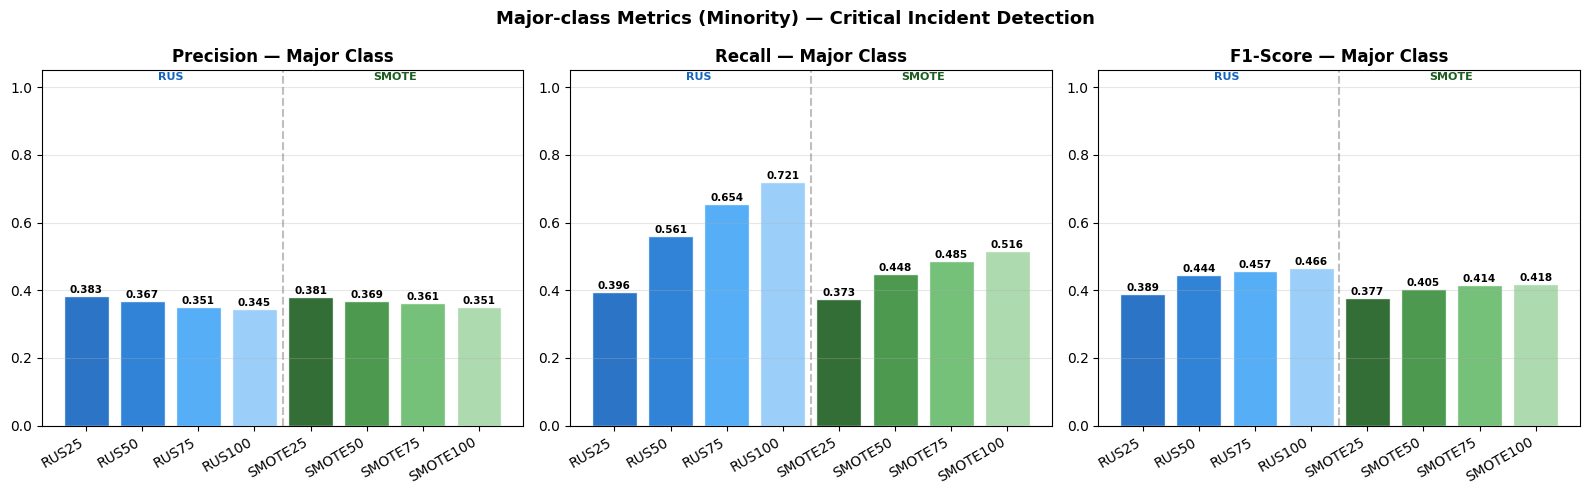

In [111]:
# 3: Major-class metrics (minority)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Major-class Metrics (Minority) — Critical Incident Detection',
             fontsize=13, fontweight='bold')

for ax, col, title in [
    (axes[0], 'prec_major', 'Precision — Major Class'),
    (axes[1], 'rec_major',  'Recall — Major Class'),
    (axes[2], 'f1_major',   'F1-Score — Major Class'),
]:
    bars = ax.bar(x_all, df_test[col], color=colors_bar, alpha=0.9, edgecolor='white')
    for bar, val in zip(bars, df_test[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax.set_xticks(x_all)
    ax.set_xticklabels(configs_names, rotation=30, ha='right')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5)
    ax.text(1.5, 1.02, 'RUS', ha='center', fontsize=8, color='#1565C0', fontweight='bold')
    ax.text(5.5, 1.02, 'SMOTE', ha='center', fontsize=8, color='#1B5E20', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

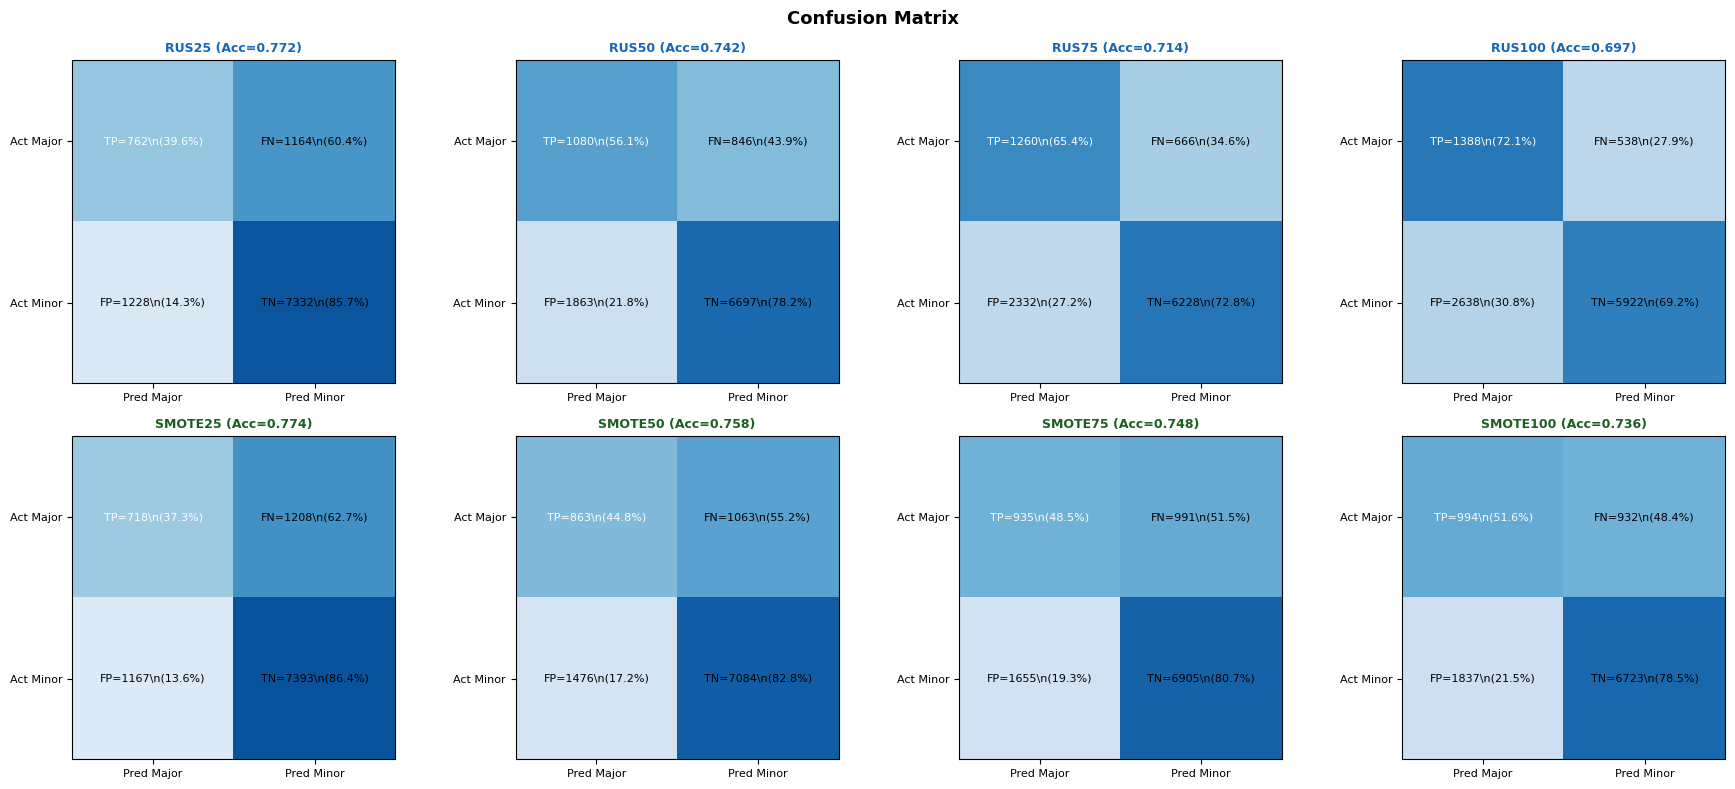

In [112]:
# 4: Confusion Matrix
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Confusion Matrix',
             fontsize=13, fontweight='bold')

for idx, (ax, (_, row)) in enumerate(zip(axes.flat, df_test.iterrows())):
    TP, FP, TN, FN = row['TP'], row['FP'], row['TN'], row['FN']
    tot_major = TP + FN
    tot_minor = TN + FP

    cm_disp = np.array([[TP, FN], [FP, TN]])
    im = ax.imshow([[TP/tot_major, FN/tot_major],
                    [FP/tot_minor, TN/tot_minor]],
                   cmap='Blues', vmin=0, vmax=1)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred Major', 'Pred Minor'], fontsize=8)
    ax.set_yticklabels(['Act Major', 'Act Minor'], fontsize=8)

    labels = [[f'TP={TP}\\n({TP/tot_major*100:.1f}%)', f'FN={FN}\\n({FN/tot_major*100:.1f}%)'],
               [f'FP={FP}\\n({FP/tot_minor*100:.1f}%)', f'TN={TN}\\n({TN/tot_minor*100:.1f}%)']]
    for i in range(2):
        for j in range(2):
            color = 'white' if (i == 0 and j == 0) else 'black'
            ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=8, color=color)

    method_color = '#1565C0' if row['method'] == 'RUS' else '#1B5E20'
    ax.set_title(f"{row['name']} (Acc={row['acc']:.3f})",
                 fontsize=9, fontweight='bold', color=method_color)

plt.tight_layout()
plt.show()

## Insights and Summary

In [113]:
# Summary table
print("Model Insights\n")
print(f"{'Config':<10} {'Rasio':>6} {'N-Train':>8} "
      f"{'CV-Acc':>11} {'CV-F1':>9} "
      f"{'Test-Acc':>7} {'Test-F1':>7} {'AUC':>7} "
      f"{'Prec-Maj':>9} {'Rec-Maj':>8} {'F1-Maj':>7}")
print("-"*100)

prev_method = ''
for _, row_t in df_test.iterrows():
    row_cv = df_cv[df_cv['name'] == row_t['name']].iloc[0]
    if row_t['method'] != prev_method and prev_method != '':
        print("-"*100)
    prev_method = row_t['method']
    print(f"{row_t['name']:<10} {row_t['label']:>6} {row_t['n_train']:>8.0f} "
          f"{row_cv['cv_acc']:.3f} {row_cv['cv_f1']:.3f} "
          f"{row_t['acc']:>9.3f} {row_t['f1_w']:>8.3f} {row_t['auc']:>7.3f} "
          f"{row_t['prec_major']:>9.3f} {row_t['rec_major']:>8.3f} {row_t['f1_major']:>7.3f}")

Model Insights

Config      Rasio  N-Train      CV-Acc     CV-F1 Test-Acc Test-F1     AUC  Prec-Maj  Rec-Maj  F1-Maj
----------------------------------------------------------------------------------------------------
RUS25         25%    38525 0.770 0.771     0.772    0.773   0.780     0.383    0.396   0.389
RUS50         50%    23115 0.738 0.756     0.742    0.760   0.787     0.367    0.561   0.444
RUS75         75%    17978 0.713 0.740     0.714    0.742   0.786     0.351    0.654   0.457
RUS100       100%    15410 0.696 0.728     0.697    0.729   0.788     0.345    0.721   0.466
----------------------------------------------------------------------------------------------------
SMOTE25       25%    42795 0.771 0.770     0.774    0.773   0.774     0.381    0.373   0.377
SMOTE50       50%    51354 0.754 0.763     0.758    0.767   0.773     0.369    0.448   0.405
SMOTE75       75%    59913 0.743 0.758     0.748    0.761   0.768     0.361    0.485   0.414
SMOTE100     100%    68472 0.7

In [114]:
# Analysis
print("RUS vs SMOTE")

df_rus_t   = df_test[df_test['method'] == 'RUS']
df_smote_t = df_test[df_test['method'] == 'SMOTE']

best_rus   = df_rus_t.loc[df_rus_t['acc'].idxmax()]
best_smote = df_smote_t.loc[df_smote_t['acc'].idxmax()]

print(f"\nBest RUS   : {best_rus['name']}")
print(f"  Accuracy = {best_rus['acc']:.4f} | F1 = {best_rus['f1_w']:.4f} | AUC = {best_rus['auc']:.4f}")
print(f"  Recall Major = {best_rus['rec_major']:.4f} | N_train = {best_rus['n_train']:,}")

print(f"\nBest SMOTE : {best_smote['name']}")
print(f"  Accuracy = {best_smote['acc']:.4f} | F1 = {best_smote['f1_w']:.4f} | AUC = {best_smote['auc']:.4f}")
print(f"  Recall Major = {best_smote['rec_major']:.4f} | N_train = {best_smote['n_train']:,}")

print("\n" + "-"*70)
print("Effect of resampling ratio on Recall Major (critical incident detection):")
for _, row in df_test.iterrows():
    bar = "█" * int(row['rec_major'] * 30)
    print(f"  {row['name']:<12} {row['rec_major']:.4f}  {bar}")

print("\n" + "-"*70)
print("Conclusion:")

overall_best = df_test.loc[df_test['acc'].idxmax()]
auc_best     = df_test.loc[df_test['auc'].idxmax()]
rec_maj_best = df_test.loc[df_test['rec_major'].idxmax()]

print(f"  1. Best configuration (Accuracy): {overall_best['name']} ({overall_best['acc']:.4f})")
print(f"  2. Best configuration (AUC): {auc_best['name']} ({auc_best['auc']:.4f})")
print(f"  3. Best configuration (Recall Major): {rec_maj_best['name']} ({rec_maj_best['rec_major']:.4f})")
print(f"  4. SMOTE preserves more information than RUS")
print(f"     (N_train RUS100 = {df_test[df_test['name']=='RUS100']['n_train'].values[0]:.0f} "
      f"vs SMOTE100 = {df_test[df_test['name']=='SMOTE100']['n_train'].values[0]:.0f})")
print(f"  5. As resampling ratio increases, recall for the major class tends to increase")

RUS vs SMOTE

Best RUS   : RUS25
  Accuracy = 0.7719 | F1 = 0.7733 | AUC = 0.7802
  Recall Major = 0.3956 | N_train = 38,525

Best SMOTE : SMOTE25
  Accuracy = 0.7735 | F1 = 0.7726 | AUC = 0.7742
  Recall Major = 0.3728 | N_train = 42,795

----------------------------------------------------------------------
Effect of resampling ratio on Recall Major (critical incident detection):
  RUS25        0.3956  ███████████
  RUS50        0.5607  ████████████████
  RUS75        0.6542  ███████████████████
  RUS100       0.7207  █████████████████████
  SMOTE25      0.3728  ███████████
  SMOTE50      0.4481  █████████████
  SMOTE75      0.4855  ██████████████
  SMOTE100     0.5161  ███████████████

----------------------------------------------------------------------
Conclusion:
  1. Best configuration (Accuracy): SMOTE25 (0.7735)
  2. Best configuration (AUC): RUS100 (0.7882)
  3. Best configuration (Recall Major): RUS100 (0.7207)
  4. SMOTE preserves more information than RUS
     (N_train RU

In [115]:
# Export results for documentation
df_cv_export = df_cv[['name', 'method', 'label', 'cv_acc', 'cv_acc_std',
                       'cv_prec', 'cv_rec', 'cv_f1', 'cv_f1_std']].copy()
df_cv_export.columns = ['config', 'method', 'ratio', 'cv_accuracy', 'cv_acc_std',
                         'cv_precision', 'cv_recall', 'cv_f1', 'cv_f1_std']

df_test_export = df_test[['name', 'method', 'label', 'n_train',
                           'acc', 'prec_w', 'rec_w', 'f1_w', 'auc',
                           'prec_minor', 'rec_minor', 'f1_minor',
                           'prec_major', 'rec_major', 'f1_major',
                           'TP', 'FP', 'TN', 'FN']].copy()
df_test_export.columns = [
    'config', 'method', 'ratio', 'n_train',
    'test_accuracy', 'test_precision_w', 'test_recall_w', 'test_f1_w', 'test_auc',
    'precision_minor', 'recall_minor', 'f1_minor',
    'precision_major', 'recall_major', 'f1_major',
    'TP', 'FP', 'TN', 'FN',
]

df_cv_export.to_csv('results_cv_ratio_variation.csv', index=False)
df_test_export.to_csv('results_test_ratio_variation.csv', index=False)

print('✓ Files saved:')
print('  - results_cv_ratio_variation.csv')
print('  - results_test_ratio_variation.csv')
print(f'\n✓ Total configurations tested: {len(CONFIGS)} (4 RUS + 4 SMOTE)')
print('✓ Notebook finished')

✓ Files saved:
  - results_cv_ratio_variation.csv
  - results_test_ratio_variation.csv

✓ Total configurations tested: 8 (4 RUS + 4 SMOTE)
✓ Notebook finished
